In [1]:
# Load necessary library
library(fs)
library("ggplot2")
library("tidyverse")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
# Define base directories for the two nested directories
beta_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2"  # Theoretical
kingman_dir2 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2"  # Empirical

# List only directories in beta_dir1 that are two levels deep
beta_subdirs1 <- list.dirs(beta_dir1, recursive = TRUE, full.names = TRUE)
beta_subdirs1 <- beta_subdirs1[sapply(strsplit(beta_subdirs1, "/"), length) == length(strsplit(beta_dir1, "/")[[1]]) + 2]

# List only directories in kingman_dir2 that are one level deep
kingman_subdirs2 <- list.dirs(kingman_dir2, recursive = TRUE, full.names = TRUE)
kingman_subdirs2 <- kingman_subdirs2[sapply(strsplit(kingman_subdirs2, "/"), length) == length(strsplit(kingman_dir2, "/")[[1]]) + 1]

# Initialize a list to store matches
matches <- list()

# Loop through each theoretical directory
for (beta_dir in beta_subdirs1) {
  # Get the second-to-last directory name (e.g., "m1e-10")
  second_last_dir <- dirname(beta_dir)  # Get the parent directory
  second_to_last_beta_dir <- basename(second_last_dir)  # This gets the second-to-last directory name
  
  # Find matching empirical directories based on the last directory name
  matching_dirs <- kingman_subdirs2[grepl(second_to_last_beta_dir, kingman_subdirs2)]
  
  # If there are matching empirical directories, store them in a structured way
  if (length(matching_dirs) > 0) {
    for (kingman_dir in matching_dirs) {
      # Initialize list if it doesn't exist
      if (!is.null(matches[[kingman_dir]])) {
        matches[[kingman_dir]] <- c(matches[[kingman_dir]], beta_dir)
      } else {
        matches[[kingman_dir]] <- list(beta_dir)
      }
    }
  }
}

# Format the output for better readability
formatted_matches <- lapply(names(matches), function(kingman) {
  list(
    kingman = kingman,
    beta_dirs = matches[[kingman]]
  )
})

# Display the summarized matches
print("Summarized Matches:")
print(formatted_matches)


[1] "Summarized Matches:"
[[1]]
[[1]]$kingman
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2/m1e-10"

[[1]]$beta_dirs
[[1]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.5"

[[1]]$beta_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.7"

[[1]]$beta_dirs[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.9"



[[2]]
[[2]]$kingman
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2/m1e-6"

[[2]]$beta_dirs
[[2]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/tr

In [4]:
# Initialize a list to store the paths of .rds files
txt_files_list <- list()

# Loop through each matched directory
for (i in seq_along(formatted_matches)) {
  # Get the kingman directory
  kingman_dir <- formatted_matches[[i]]$kingman
  txt_files_kingman <- list.files(path = kingman_dir, pattern = "final.txt$", full.names = TRUE)
  
  # Get the beta directories
  beta_dirs <- formatted_matches[[i]]$beta_dirs
  txt_files_beta <- unlist(lapply(beta_dirs, function(beta_dir) {
    list.files(path = beta_dir, pattern = "final.txt$", full.names = TRUE)
  }))
  
  # Store the results in the list
  txt_files_list[[i]] <- list(
    kingman = txt_files_kingman,
    beta_dirs = txt_files_beta
  )
}

# Print the list of txt files
print(txt_files_list)

[[1]]
[[1]]$kingman
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2/m1e-10/Popsize_Kingman_bottleneck_rep2_m1e-10_ratio999.9999999999999_rs1525227.msmc2.final.txt"
[2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2/m1e-10/Popsize_Kingman_bottleneck_rep4_m1e-10_ratio999.9999999999999_rs1525229.msmc2.final.txt"
[3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_kingman/trial2/m1e-10/Popsize_Kingman_bottleneck_rep6_m1e-10_ratio999.9999999999999_rs1525231.msmc2.final.txt"

[[1]]$beta_dirs
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/MSMC2_out/msmc_beta/trial2/m1e-10/alpha1.5/Popsize_Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.msmc2.final.txt"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/m

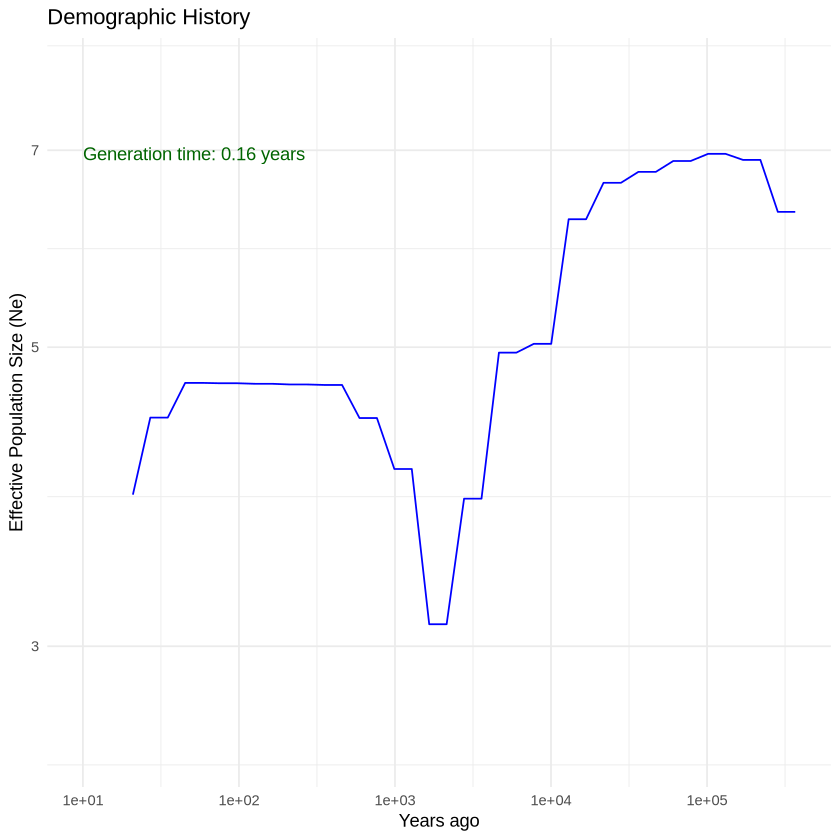

In [5]:

# Provided demography data
demography_data <- data.frame(
  years_ago = c(20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
                75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
                273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
                990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
                3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
                12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
                46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
                169890.48403, 219724.30843, 284175.84417, 367532.89150),
  Ne_log10 = c(3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
               4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
               4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
               4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
               3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
               6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
               6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
               6.885372, 6.885372, 6.300497, 6.300497)
)

# Convert years_ago to generations_ago (assuming generation time of 0.16 years)

# Convert Ne_log10 to actual Ne values

# Plotting using ggplot2
ggplot(demography_data, aes(x = years_ago, y = Ne_log10)) +
  geom_line(color = "blue") +
  scale_x_log10() +
  scale_y_log10(limits = c(2.5, 8)) +  # Adjusting y-axis limits
  labs(title = "Demographic History",
       x = "Years ago",
       y = "Effective Population Size (Ne)") +
  theme_minimal() +
  annotate("text", x = 10, y = max(demography_data$Ne_log10, na.rm = TRUE), 
           label = "Generation time: 0.16 years", hjust = 0, color = "darkgreen")


In [10]:
# Constants
mu <- 1e-06
gen_times <- 25

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(txt_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[1]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(txt_files_list[[2]]$kingman)) {
    kingman_dir <- txt_files_list[[2]]$kingman[j]
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    
    if (file.exists(kingman_dir)) {
      data_msmc <- read.table(kingman_dir, header=T)  # Read the .rds file
      
      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]]$kingman[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(txt_files_list[[2]]$beta)) {
    beta_dir <- txt_files_list[[2]]$beta[j]

    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_msmc <- read.table(beta_dir, header=T)  # Read the .rds file

      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",second_last_component,"_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]]$beta[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



In [11]:
# Create a color palette for the alpha values
alpha_values <- unique(unlist(lapply(individual_data_frames[[1]]$beta, function(df) df$alpha)))
colors <- rainbow(length(alpha_values))  # Generate colors for each alpha


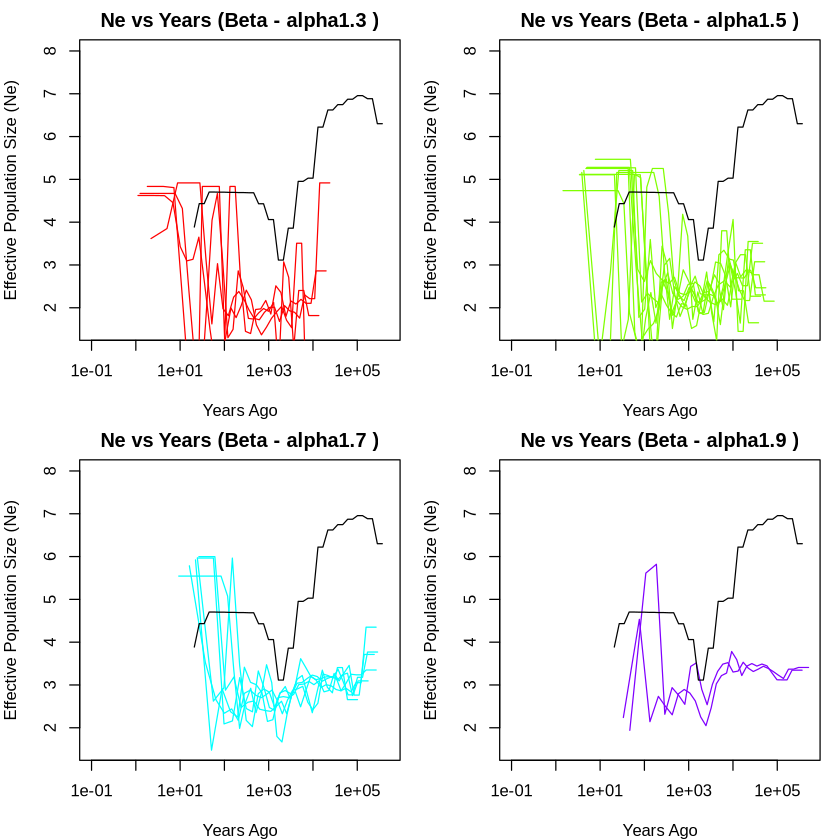

In [12]:
par(bg="white")
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1))  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[1]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


In [13]:
# Combine 'beta' data into a single data frame for ggplot
beta_combined <- bind_rows(lapply(individual_data_frames[[1]]$beta, function(df) df), .id = "label")

# Convert 'label' to factor for better handling in ggplot
beta_combined$label <- as.factor(beta_combined$label)

# Convert years_ago and Ne to log scale where needed and store alpha as a factor
beta_combined <- beta_combined %>% 
  mutate(alpha = factor(alpha, levels = alpha_values))

str(beta_combined$Ne)
  

 num [1:672] 4.84 4.84 4.84 4.81 2.25 ...


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in scale_x_log10(limits = c(0.1, 5e+05), breaks = scales::log_breaks(base = 10)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(limits = c(0.1, 5e+05), breaks = scales::log_breaks(base = 10)):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


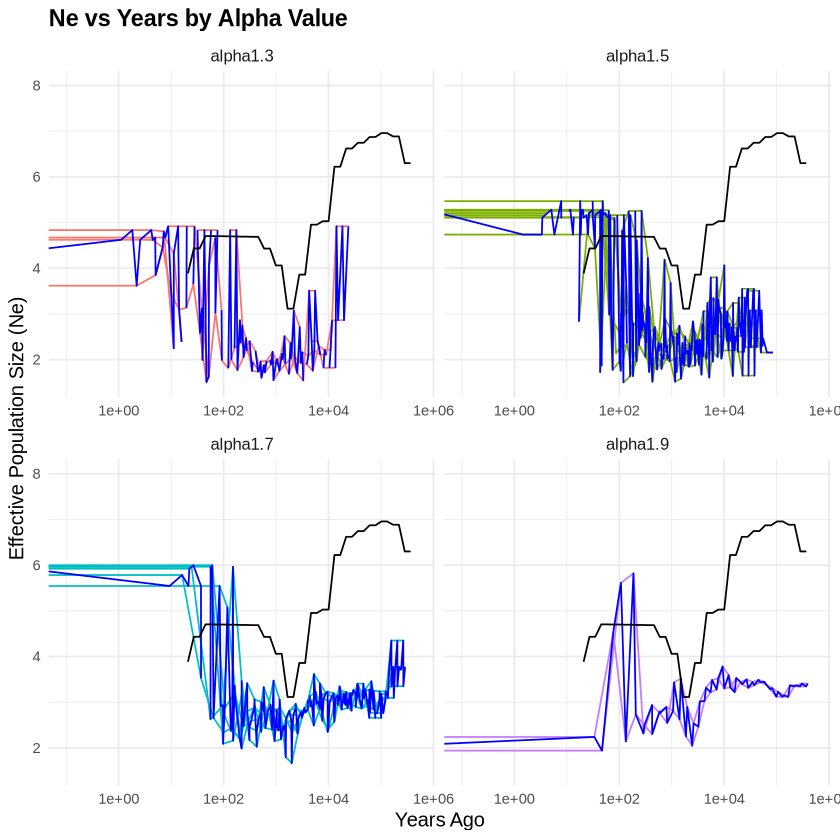

In [14]:
library(ggplot2)
library(dplyr)

# Calculate the mean Ne for each years_ago and alpha combination
beta_mean <- beta_combined %>%
  group_by(alpha, years_ago) %>%
  summarize(Ne_mean = mean(Ne, na.rm = TRUE), .groups = 'drop')

# Plot using ggplot2 with facets for each alpha value
ggplot(data = beta_combined, aes(x = years_ago, y = Ne, color = alpha, group = label)) +
  geom_line() +  # Plot each individual line from beta_combined
  geom_line(data = beta_mean, aes(x = years_ago, y = Ne_mean), color = "blue", size = 0.5, linetype = "solid") +  # Mean line for each alpha
  geom_line(data = demography_data, aes(x = years_ago, y = Ne_log10), color = "black", size = 0.5) +  # Black demography line
  scale_x_log10(limits = c(0.1, 500000), breaks = scales::log_breaks(base = 10)) +
  scale_y_continuous(limits = c(1.5, 8)) +
  labs(x = "Years Ago", y = "Effective Population Size (Ne)", title = "Ne vs Years by Alpha Value") +
  facet_wrap(~ alpha, scales = "free_x", nrow = 2, ncol = 2) +  # Arrange facets in 2x2 layout
  theme_minimal() +
  theme(legend.position = "none",  # Hide legend if not needed
        strip.text = element_text(size = 10),
        axis.title = element_text(size = 12),
        plot.title = element_text(size = 14, face = "bold"))



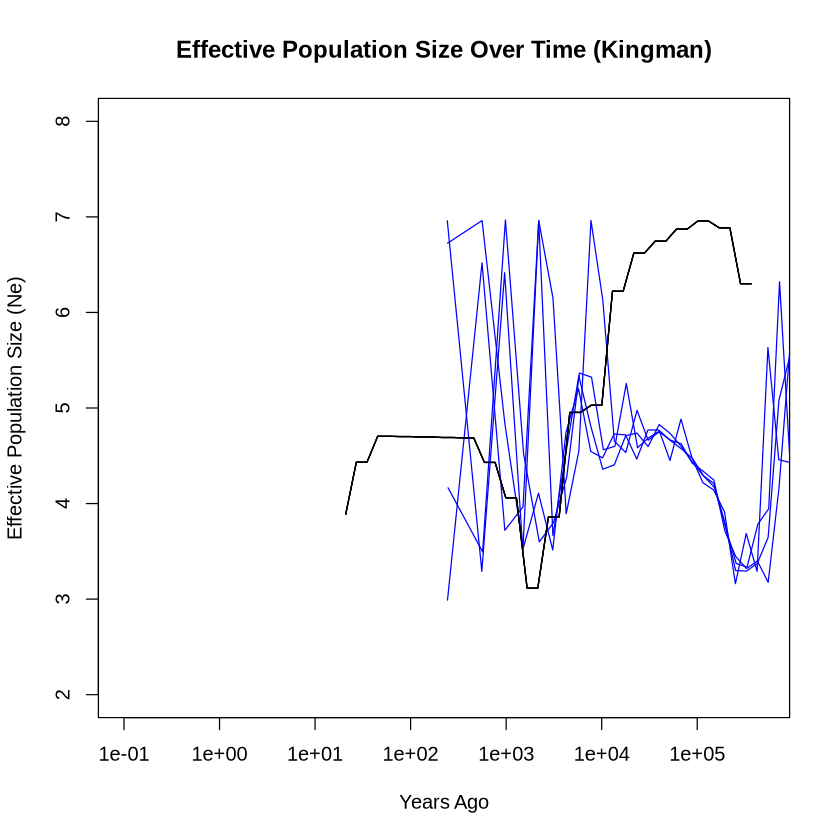

In [15]:
par(bg="white")

# Plot setup for Kingman lines
plot(NULL, xlim = c(0.1, 500000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "x")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[1]]$kingman)) {
  lines(individual_data_frames[[1]]$kingman[[i]]$years_ago, 
        individual_data_frames[[1]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
        # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}



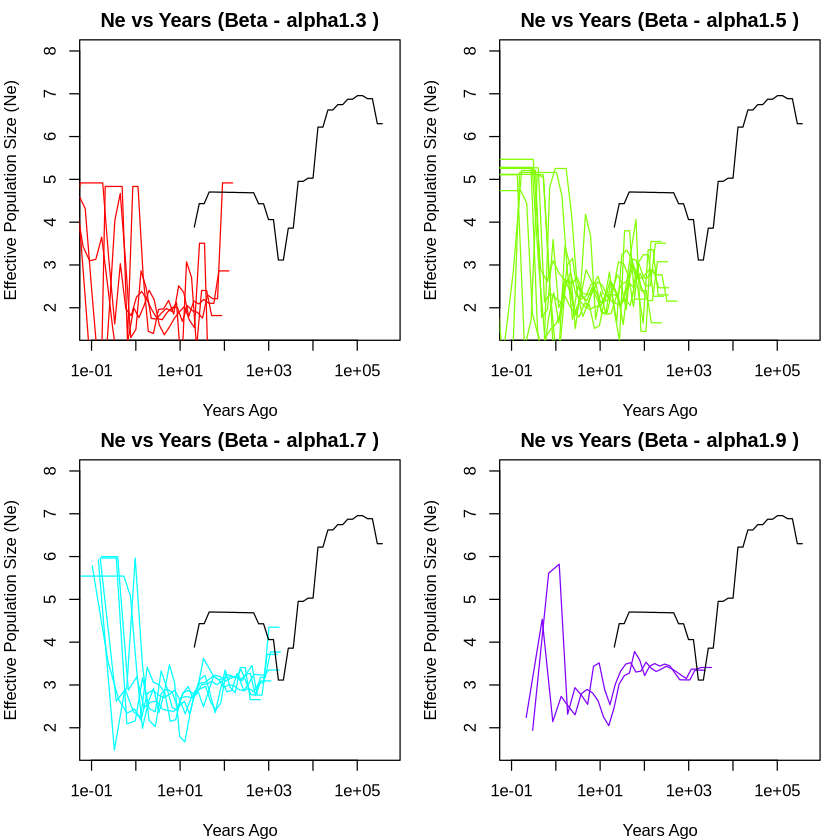

In [ ]:
# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1),bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[1]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))

m1e-07

In [25]:
# Constants
mu <- 1e-07
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[2]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(txt_files_list[[3]]$kingman)) {
    kingman_dir <- txt_files_list[[3]]$kingman[j]

    if (file.exists(kingman_dir)) {
      data_msmc <- read.table(kingman_dir, header=T)  # Read the .rds file
      
      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]]$kingman[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(txt_files_list[[3]]$beta)) {
    beta_dir <- txt_files_list[[3]]$beta[j]

    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_msmc <- read.table(beta_dir, header=T)  # Read the .rds file

      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]]$beta[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}


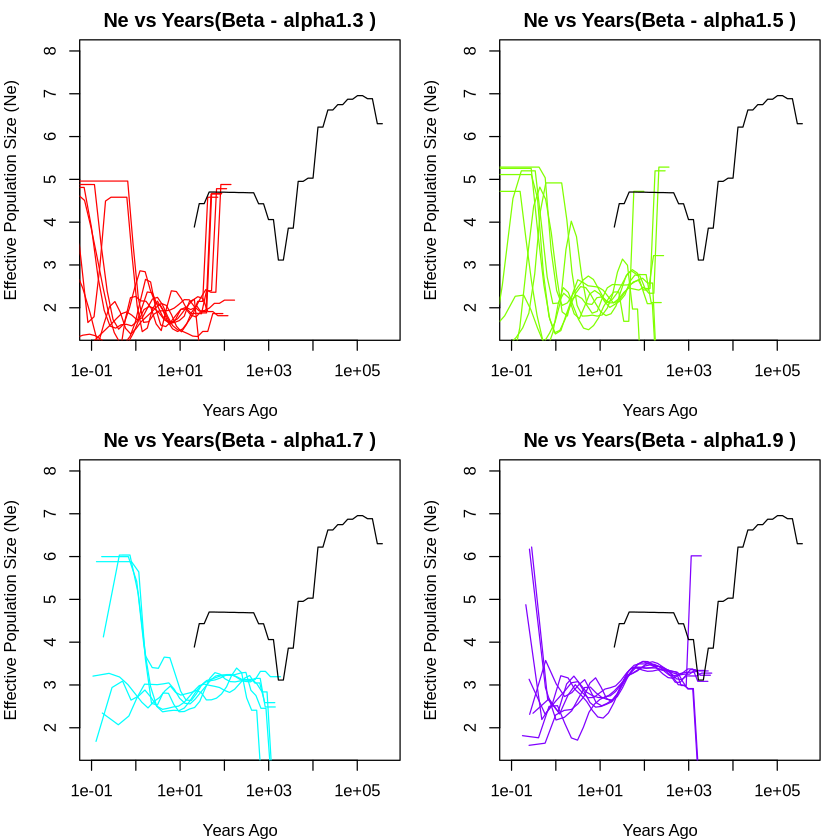

In [26]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1),bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[2]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))

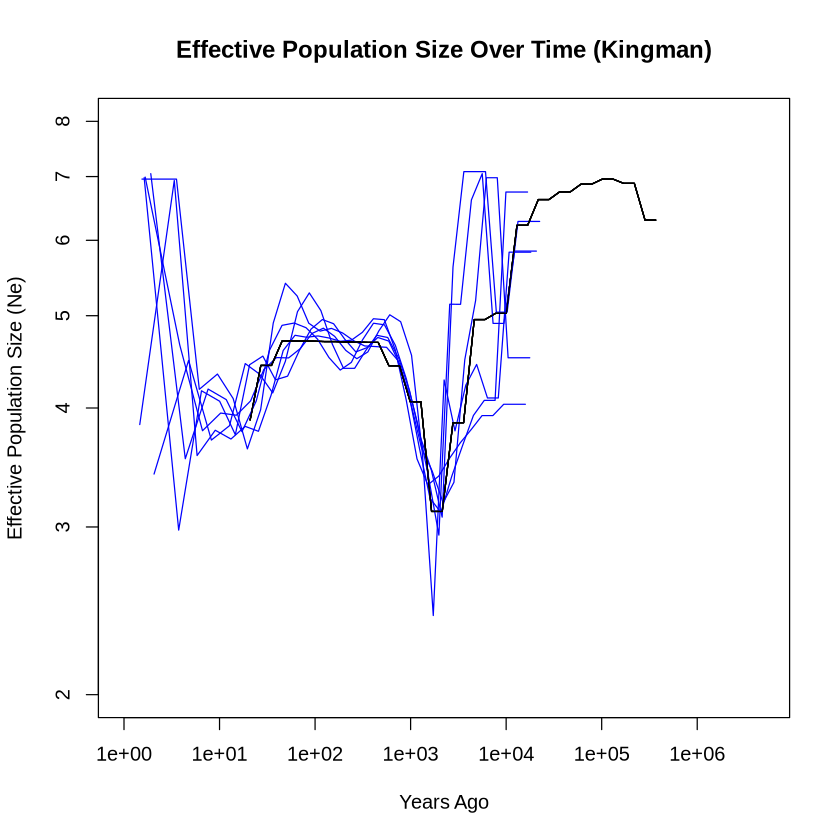

In [28]:

par(bg="white")
# Plot setup for Kingman lines
plot(NULL, xlim = c(1, 5000000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[2]]$kingman)) {
  lines(individual_data_frames[[2]]$kingman[[i]]$years_ago, 
        individual_data_frames[[2]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
          # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}



m1e-08

In [29]:
# Constants
mu <- 1e-08
gen_times <- 0.16

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(txt_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[3]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(txt_files_list[[4]]$kingman)) {
    kingman_dir <- txt_files_list[[4]]$kingman[j]
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    
    if (file.exists(kingman_dir)) {
      data_msmc <- read.table(kingman_dir, header=T)  # Read the .rds file
      
      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[3]]$kingman[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(txt_files_list[[4]]$beta)) {
    beta_dir <- txt_files_list[[4]]$beta[j]

    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_msmc <- read.table(beta_dir, header=T)  # Read the .rds file

      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",second_last_component,"_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[3]]$beta[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



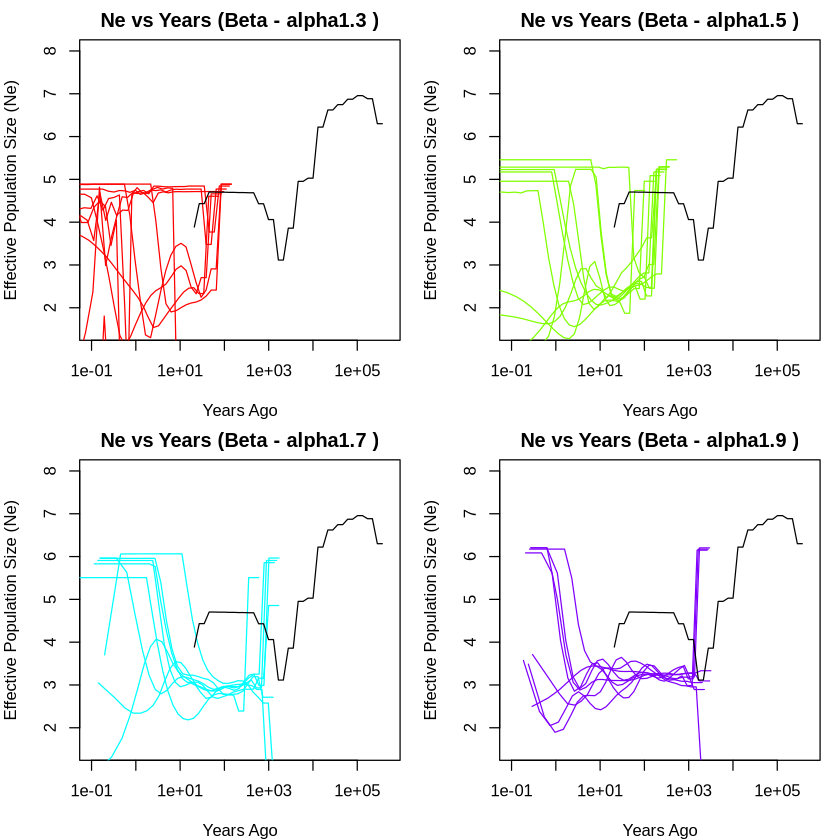

In [30]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[3]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))



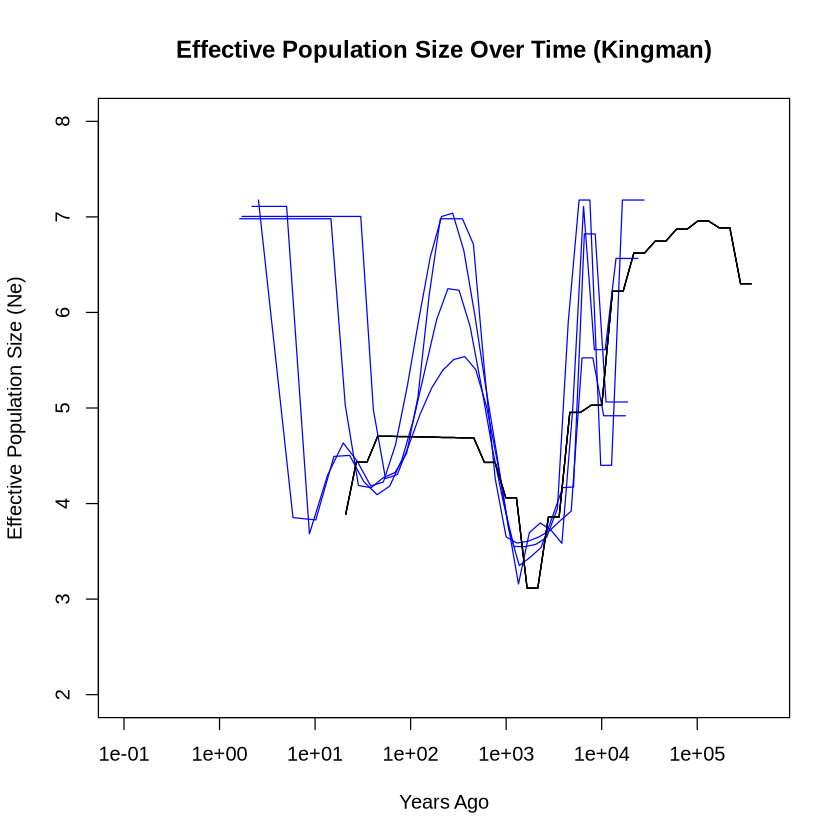

In [15]:


# Plot setup for Kingman lines
plot(NULL, xlim = c(0.1, 500000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "x")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[3]]$kingman)) {
  lines(individual_data_frames[[3]]$kingman[[i]]$years_ago, 
        individual_data_frames[[3]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
        # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}





In [31]:
# Constants
mu <- 1e-09
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[4]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(txt_files_list[[5]]$kingman)) {
    kingman_dir <- txt_files_list[[5]]$kingman[j]

    if (file.exists(kingman_dir)) {
      data_msmc <- read.table(kingman_dir, header=T)  # Read the .rds file
      
      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[4]]$kingman[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(txt_files_list[[5]]$beta)) {
    beta_dir <- txt_files_list[[5]]$beta[j]

    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_msmc <- read.table(beta_dir, header=T)  # Read the .rds file

      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[4]]$beta[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



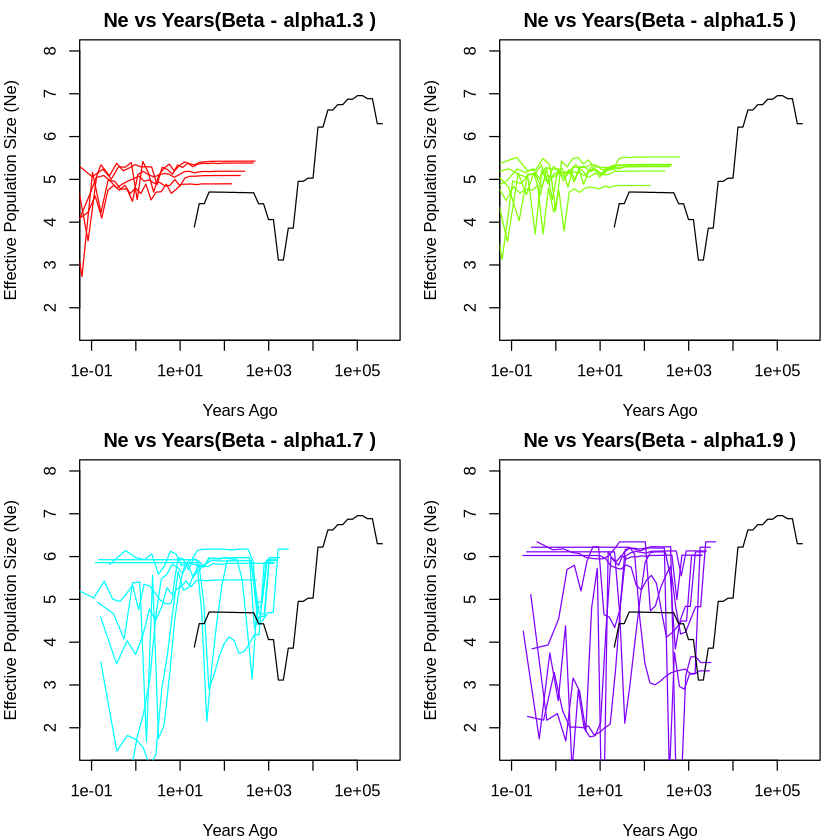

In [33]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[4]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


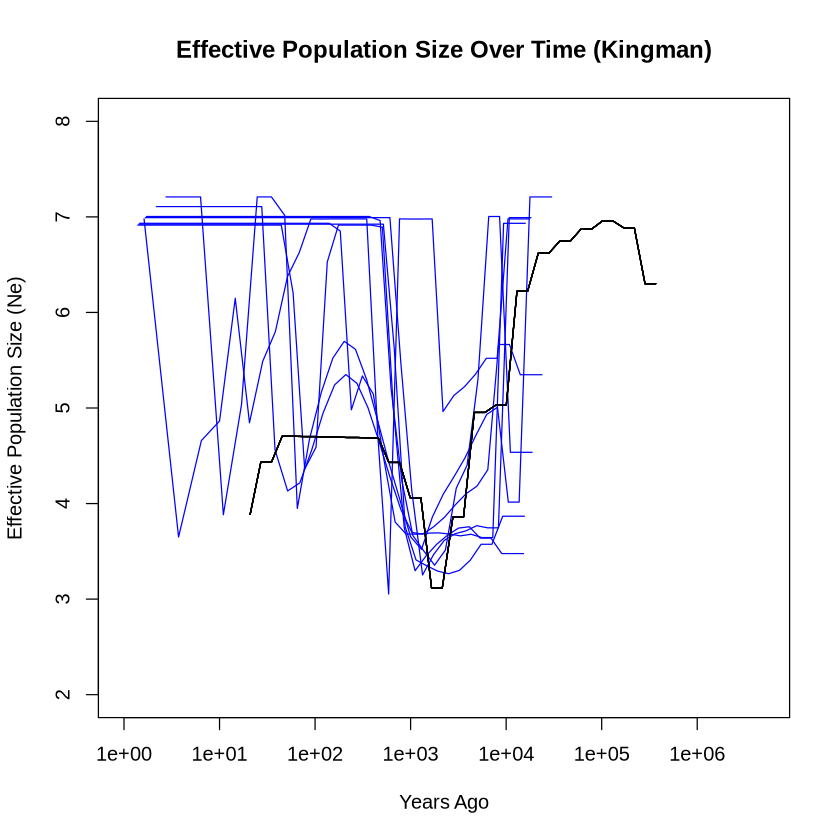

In [35]:
par(bg="white")
# Plot setup for Kingman lines
plot(NULL, xlim = c(1, 5000000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "x")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[4]]$kingman)) {
  lines(individual_data_frames[[4]]$kingman[[i]]$years_ago, 
        individual_data_frames[[4]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
          # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}



1e-10

In [36]:
# Constants
mu <- 1e-10
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[5]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(txt_files_list[[1]]$kingman)) {
    kingman_dir <- txt_files_list[[1]]$kingman[j]

    if (file.exists(kingman_dir)) {
      data_msmc <- read.table(kingman_dir, header=T)  # Read the .rds file
      
      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[5]]$kingman[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(txt_files_list[[1]]$beta)) {
    beta_dir <- txt_files_list[[1]]$beta[j]

    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_msmc <- read.table(beta_dir, header=T)  # Read the .rds file

      data_msmc$years_ago <- (data_msmc$left_time_boundary) / mu * gen_times
      data_msmc$Ne <-  log10((1 / data_msmc$lambda) / mu)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[5]]$beta[[label]] <- data.frame(
        years_ago = data_msmc$years_ago,
        Ne = data_msmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



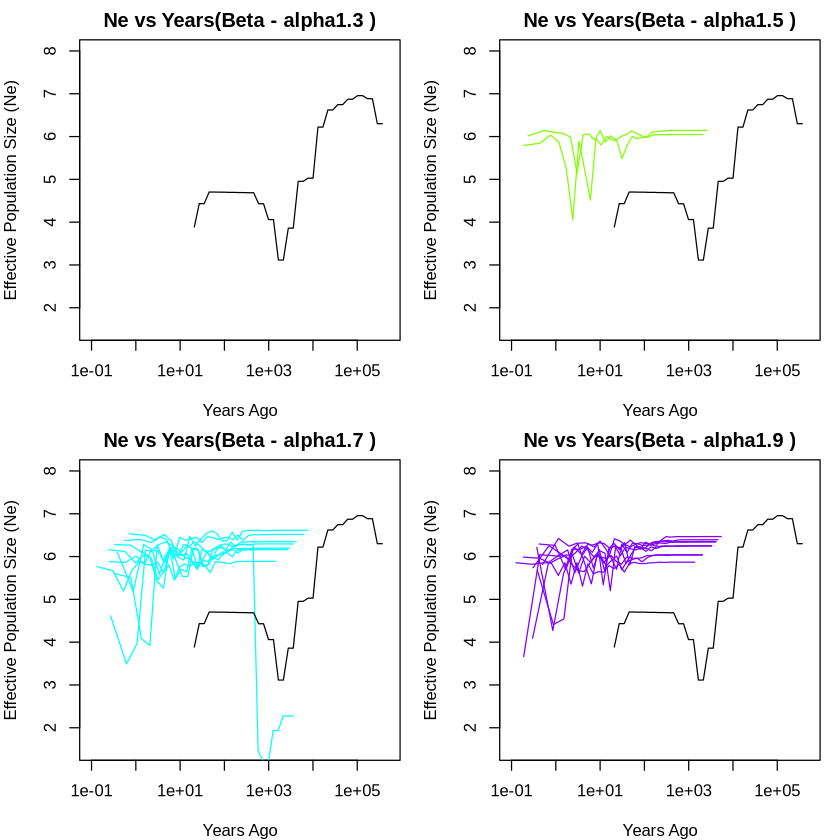

In [37]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[5]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


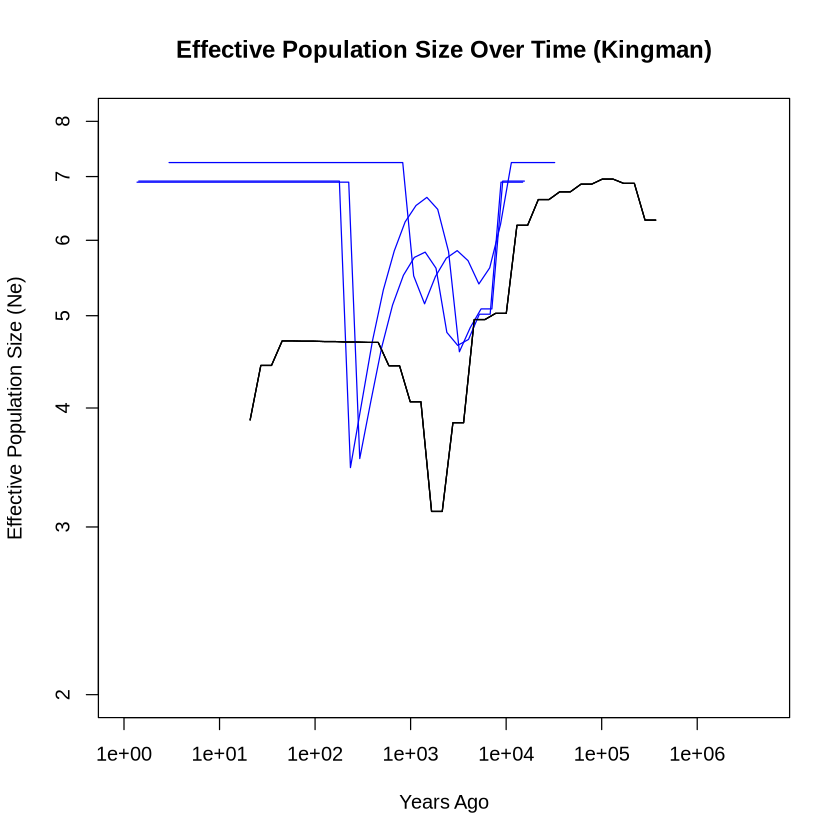

In [21]:
# Plot setup for Kingman lines
plot(NULL, xlim = c(1, 5000000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[5]]$kingman)) {
  lines(individual_data_frames[[5]]$kingman[[i]]$years_ago, 
        individual_data_frames[[5]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
          # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

